# Full Comparison — TF-IDF vs SBERT vs Transformer

## Goal
Side-by-side comparison of all three versions on the same sentences.
Which method best captures semantic similarity?

## Methods
- v1: TF-IDF + Cosine Similarity
- v2: SBERT (all-MiniLM-L6-v2)
- v3: DistilBERT + Mean Pooling

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch

# 1. Define Test Sentences

In [5]:
sentences = [
    # ML (0-2)
    "Machine learning models learn from data",
    "AI systems improve through training on examples",
    "Algorithms extract patterns from datasets",
    # Weather (3-5)
    "The weather today is sunny and warm",
    "It is a beautiful clear day outside",
    "The sky is bright and the temperature is high",
    # Food (6-8)
    "I love eating pizza and pasta",
    "Italian cuisine is my favorite food",
    "Nothing beats a good slice of pizza",
]

true_groups = ["ML"] * 3 + ["Weather"] * 3 + ["Food"] * 3
labels = [f"S{i+1}" for i in range(len(sentences))]

print(f"Total sentences: {len(sentences)}")

Total sentences: 9


## 2. Compute Similarities for All Methods

In [6]:
# --- Method 1: TF-IDF ---
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(sentences)
tfidf_sim = cosine_similarity(tfidf_matrix)

# --- Method 2: SBERT ---
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
sbert_embeddings = sbert_model.encode(sentences)
sbert_sim = cosine_similarity(sbert_embeddings)

# --- Method 3: DistilBERT + Mean Pooling ---
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
transformer_model = AutoModel.from_pretrained(model_name)
transformer_model.eval()

def mean_pooling(texts: list) -> np.ndarray:
    embeddings = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt",
                          truncation=True, max_length=512, padding=True)
        with torch.no_grad():
            outputs = transformer_model(**inputs)
        hidden_states = outputs.last_hidden_state
        mask = inputs["attention_mask"].unsqueeze(-1).float()
        embedding = (hidden_states * mask).sum(1) / mask.sum(1)
        embeddings.append(embedding.squeeze().numpy())
    return np.array(embeddings)

transformer_embeddings = mean_pooling(sentences)
transformer_sim = cosine_similarity(transformer_embeddings)

print("All methods computed!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


All methods computed!


## 3. Side-by-Side Comparison

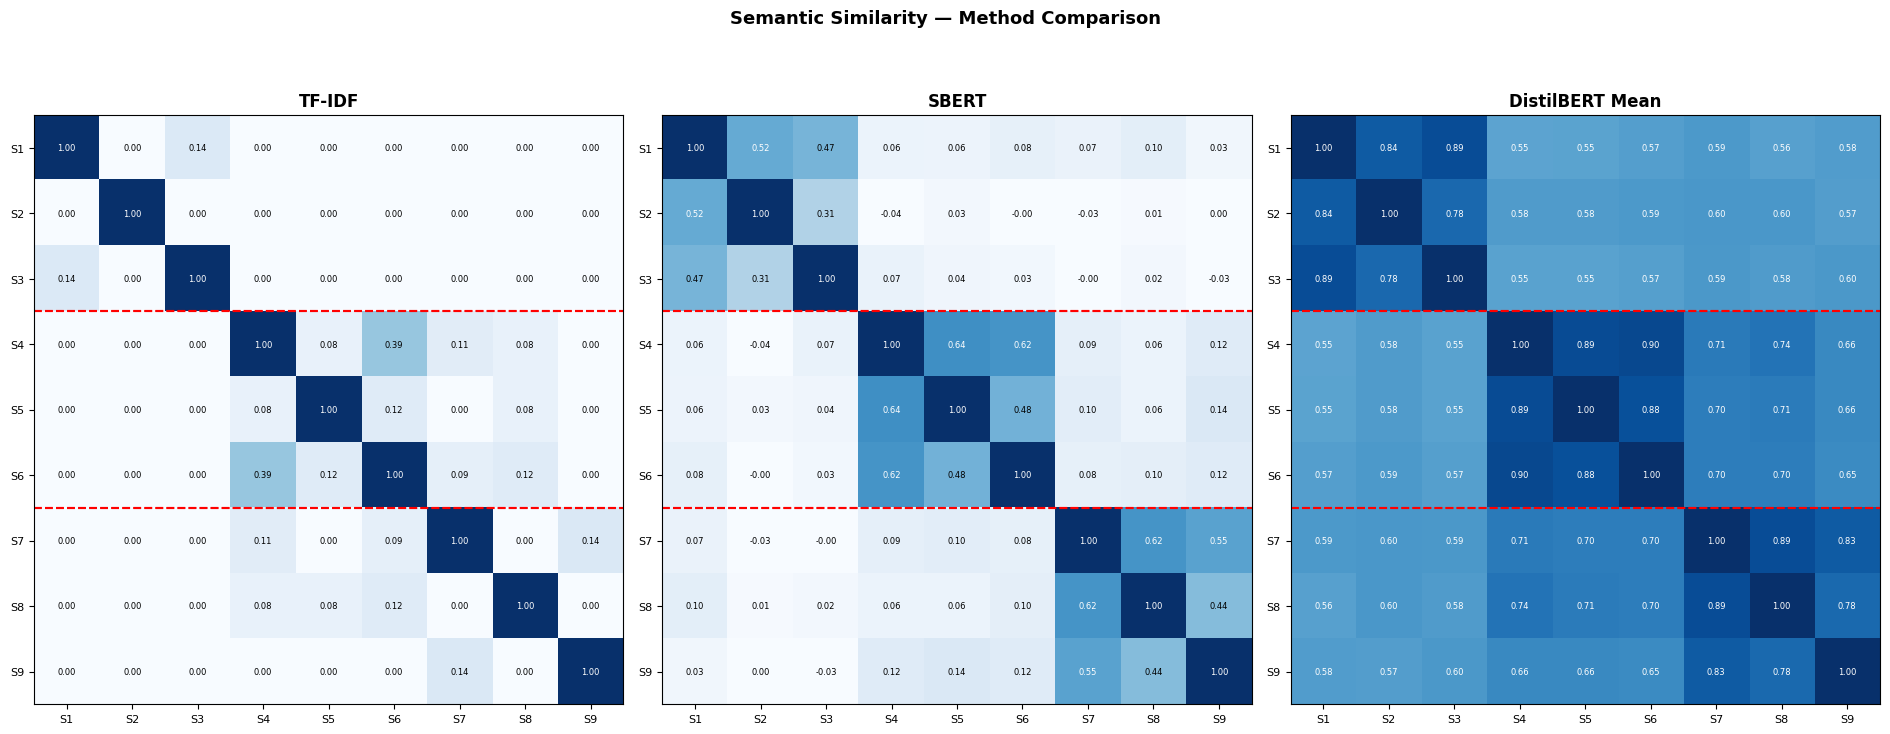

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(19, 8))
methods = [
    ("TF-IDF", tfidf_sim),
    ("SBERT", sbert_sim),
    ("DistilBERT Mean", transformer_sim)
]

for ax, (method, sim_matrix) in zip(axes, methods):
    im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(sentences)))
    ax.set_yticks(range(len(sentences)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

    for i in range(len(sentences)):
        for j in range(len(sentences)):
            ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
                   ha="center", va="center", fontsize=6,
                   color="white" if sim_matrix[i,j] > 0.5 else "black")

    for line in [2.5, 5.5]:
        ax.axhline(line, color="red", linewidth=1.5, linestyle="--")
        ax.axhline(line, color="red", linewidth=1.5, linestyle="--")

    ax.set_title(method, fontsize=12, fontweight="bold")

plt.suptitle("Semantic Similarity — Method Comparison",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("method_comparison.png", dpi=300)
plt.show()

## 4. PCA Visualization
How do sentences cluster in 2D space for each method?

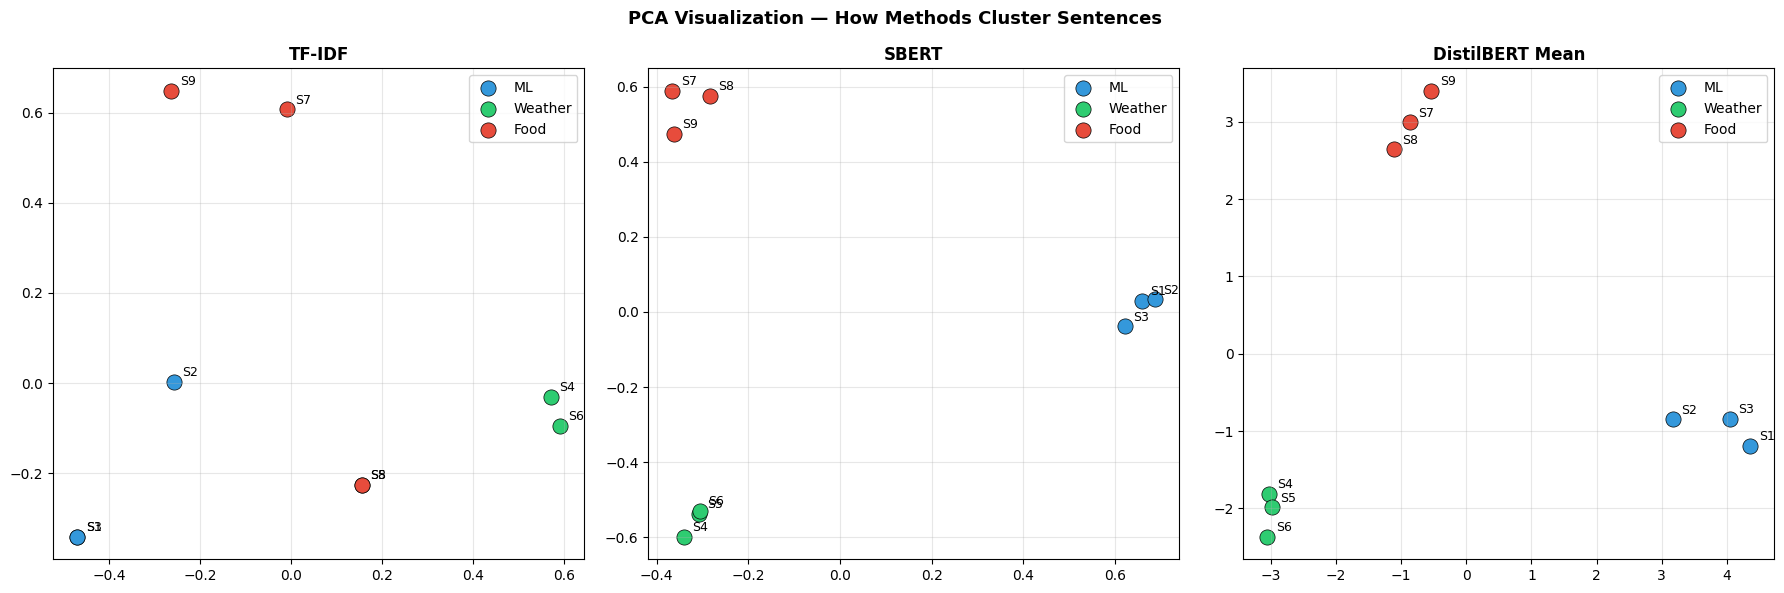

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {"ML": "#3498db", "Weather": "#2ecc71", "Food": "#e74c3c"}
methods_embeddings = [
    ("TF-IDF", tfidf_matrix.toarray()),
    ("SBERT", sbert_embeddings),
    ("DistilBERT Mean", transformer_embeddings)
]

for ax, (method, embeddings) in zip(axes, methods_embeddings):
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(embeddings)
    
    for group in ["ML", "Weather", "Food"]:
        indices = [i for i, g in enumerate(true_groups) if g == group]
        ax.scatter(
            vectors_2d[indices, 0],
            vectors_2d[indices, 1],
            c=colors[group],
            label=group,
            s=120,
            edgecolors="black",
            linewidth=0.5
        )
        for i in indices:
            ax.annotate(f"S{i+1}",
                       (vectors_2d[i, 0], vectors_2d[i, 1]),
                       textcoords="offset points",
                       xytext=(6, 4), fontsize=9)
    
    ax.set_title(method, fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("PCA Visualization — How Methods Cluster Sentences",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pca_comparison.png", dpi=150)
plt.show()

## 5. Final Comparison Table

| Method | Within-Group Similarity | Between-Group Similarity | Cluster Quality |
|--------|------------------------|--------------------------|-----------------|
| TF-IDF | Low (0.00 - 0.14) | ~0.00 | Poor |
| SBERT | Medium (0.31 - 0.64) | ~0.05 | Good |
| DistilBERT Mean | High (0.78 - 0.90) | ~0.57 | Best separation |

## Key Takeaways

**TF-IDF**
- Fast, no model needed
- Only works when sentences share exact words
- Best for: keyword search, large scale retrieval

**SBERT**
- Fine-tuned for sentence similarity
- Captures meaning without shared words
- Best for: semantic search, duplicate detection

**DistilBERT Mean Pooling**
- Raw transformer without fine-tuning
- Strong within-group clustering
- But higher between-group similarity — less discriminative than SBERT

## Conclusion
For semantic similarity tasks, SBERT is the practical choice.
It balances accuracy and speed, and was specifically trained for this problem.
Raw transformers need fine-tuning to reach SBERT-level performance.